**Experiment 2: Import, preprocess, and split the datasets using scikit-learn.**

**Aim:** To import a dataset, preprocess the data, and split it into training and testing sets using scikit-learn for machine learning model development.


**Overview of Data Preprocessing and Splitting**

Data preprocessing prepares raw data for machine learning models, while splitting ensures separate datasets for training and evaluation. Key steps include:

**1. Handle Missing Values**

* Remove rows: `data_clean = data.dropna()`
* Fill with mean: `x_i = mean(X)`
* Fill with median: `x_i = median(X)`

**2. Encode Categorical Data**

* Label encoding: `y_encoded = LabelEncoder().fit_transform(y)`
* One-hot encoding: `Y_trans = OneHotEncoder().fit_transform(y).toarray()`

**3. Scale Features**

* Min-Max scaling: `x' = (x - min(X)) / (max(X) - min(X))`
* Standardization: `x' = (x - mean(X)) / std(X)`

**4. Remove Outliers**

* Keep values in range: `data_filtered = data.loc[(X >= lower) & (X <= upper)]`

**5. Train-Test Split**

* Random split:
  `X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)`
* Stratified split:
  `X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y)`

**Summary:** Clean, encode, scale, and split the dataset to prepare it for machine learning models.


**Import Required Libraries**

1. pandas is used for data handling and analysis.

2. numpy supports numerical operations.

3. matplotlib and seaborn are used for data visualization.

4. sklearn.preprocessing provides tools for data preprocessing.

5. train_test_split is used to divide the dataset into training and testing sets.

This cell imports Python libraries needed for data handling, numerical operations, visualization, and machine learning preprocessing and dataset splitting.

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Mount Google Drive**

This cell connects Google Colab to Google Drive so that datasets stored in Drive can be accessed directly in the notebook.

In [193]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Load the Dataset**

This cell reads the CSV dataset from Google Drive into a pandas DataFrame for analysis and processing.

In [194]:
file_path = '/content/drive/My Drive/Datasets For ML/Iris_with_missing_and_duplicates.csv'
iris_data = pd.read_csv(file_path)

**Display the Dataset**

This cell shows the contents of the dataset to understand the data values, missing entries, and duplicates.

In [195]:
iris_data.head(2)

,ID,SL,SW,PL,PW,Species
0,1,5.1,3.5,1.4,0.2,Setosa
1,2,4.9,3.0,1.4,0.2,Setosa


**Check Dataset Shape**

This cell displays the number of rows and columns in the dataset to understand its size.

In [196]:
iris_data.shape

(154, 6)

**View Column Names**

This cell lists all column names in the dataset to identify features and the target variable.

In [197]:
iris_data.columns

Index(['ID', 'SL', 'SW', 'PL', 'PW', 'Species'], dtype='object')

**Remove Unnecessary Column**

This step removes the ID column from the dataset because it does not contribute to model training or prediction and is only an identifier.

**iris_data.drop(columns=['ID'])**

drop() removes data from the DataFrame.

columns=['ID'] specifies the column to remove.

The ID column is removed because it is not useful for learning.

**inplace=True (optional)**

Updates the original DataFrame directly.

Without it, the result must be reassigned to iris_data.

In [198]:
iris_data.drop(columns = ['ID'], inplace = True) # or iris_data = iris_data.drop(columns = ['ID'])

**View Updated Column Names**

This shows the remaining feature and target column names after removing unnecessary columns.

**iris_data.columns**

Returns the names of all columns present in the dataset.

Used to verify available features.

In [199]:
iris_data.columns

Index(['SL', 'SW', 'PL', 'PW', 'Species'], dtype='object')

**Check Updated Dataset Shape**

This displays the number of rows and columns in the dataset after preprocessing changes.

**iris_data.shape**

Returns a tuple (rows, columns).

Helps understand dataset size.

In [200]:
iris_data.shape

(154, 5)

**Remove Duplicate Records**

This operation removes duplicate rows from the dataset to ensure data quality and prevent biased model training.

**iris_data.drop_duplicates(inplace=True)**

drop_duplicates() removes repeated rows.

inplace=True saves the changes in the same DataFrame.

Prevents duplicate data from affecting model performance.

In [201]:
iris_data.drop_duplicates(inplace = True) # or iris_data = iris_data.drop_duplicates()
iris_data.shape

(148, 5)

**Check Missing Values in Each Column**

This step identifies how many missing values are present in each column of the dataset.

**Syntax Explanation**

* `iris_data.isnull()` or `iris_data.isna()`

  * Both functions detect missing values.
  * They return `True` for missing entries and `False` otherwise.
* `.sum()`

  * Counts the number of `True` values in each column.
  * Since `True` is treated as 1, it gives the total missing values per column.


In [202]:
iris_data.isnull().sum() # or iris_data.isna().sum()

,0
SL,7
SW,0
PL,2
PW,0
Species,0


**Remove Rows with Missing Values**

This step removes all rows that contain one or more missing values to ensure the dataset is complete for model training.

**Syntax Explanation**

* `iris_data.dropna()`

  * `dropna()` removes rows that have at least one missing value.
* `iris_data1 =`

  * Stores the cleaned dataset in a new DataFrame.
  * The original dataset remains unchanged.


In [203]:
iris_data1 = iris_data.dropna()

**Verify Cleaned Dataset**

This step confirms that missing values have been removed and checks the updated size of the dataset.

**Syntax Explanation**

* `iris_data1.shape`

  * Returns the number of rows and columns after removing missing values.
* `iris_data1.isnull().sum()`

  * Checks each column again for missing values.
  * A value of zero confirms the dataset is fully cleaned.


In [204]:
iris_data1.shape

(139, 5)

In [205]:
iris_data1.isnull().sum()

,0
SL,0
SW,0
PL,0
PW,0
Species,0


**Create a Copy of the Dataset**

This step creates an independent copy of the original dataset so preprocessing can be applied without affecting the original data.

**Syntax Explanation**

* `iris_data.copy()`

  * Creates a deep copy of the DataFrame.
  * Changes made to the copy do not modify the original dataset.
* `iris_data2 =`

  * Stores the copied dataset in a new variable.
* `iris_data2.shape`

  * Displays the number of rows and columns in the copied dataset.


In [206]:
iris_data2 = iris_data.copy()
iris_data2.shape

(148, 5)

**Fill Missing Values Using Mean Imputation**

This step replaces missing values in the `SL` column with the average value of that column to retain all rows.

**Syntax Explanation**

* `iris_data2['SL']`

  * Selects the `SL` column from the DataFrame.
* `.fillna(iris_data2['SL'].mean())`

  * `fillna()` replaces missing values.
  * `mean()` calculates the average of the `SL` column.
  * Missing values are filled with this average.
* `iris_data2.isnull().sum()`

  * Rechecks each column to confirm missing values are handled.


In [207]:
iris_data2['SL'] = iris_data2['SL'].fillna(iris_data2['SL'].mean())
iris_data2.isnull().sum()

,0
SL,0
SW,0
PL,2
PW,0
Species,0


**Fill Missing Values Using Median Imputation**

This step replaces missing values in the `PL` column using the median, following the same approach as the previous step.

**Syntax Explanation**

* `iris_data2['PL']`

  * Selects the `PL` column.
* `.fillna(iris_data2['PL'].median())`

  * `fillna()` replaces missing values.
  * `median()` computes the middle value of the column.
  * Missing values are filled with the median.
* `iris_data2.isnull().sum()`

  * Verifies that missing values are handled, same as above.


In [208]:
iris_data2['PL'] = iris_data2['PL'].fillna(iris_data2['PL'].median())
iris_data2.isnull().sum()

,0
SL,0
SW,0
PL,0
PW,0
Species,0


**Visualize Relationship Between Two Features**

This step creates a scatter plot to observe the relationship between `SL` and `PL`.

**Syntax Explanation**

* `plt.scatter(x, y)`

  * Draws a scatter plot.
* `iris_data2['SL']`

  * Values on the X-axis.
* `iris_data2['PL']`

  * Values on the Y-axis.
* Each point represents one data record.


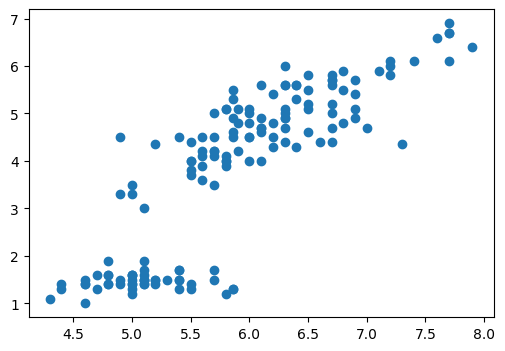

In [209]:
plt.figure(figsize = (6, 4))
plt.scatter(iris_data2['SL'], iris_data2['PL'])

**Visualize Data Distribution and Outliers**

This step displays a boxen plot to analyze the distribution and identify outliers across all numerical features.

**Syntax Explanation**

* `sns.boxenplot(data)`

  * Creates a boxen plot using Seaborn.
* `iris_data2`

  * The dataset passed to the plot.
* Helps compare spread and detect extreme values in each feature.


<Axes: >

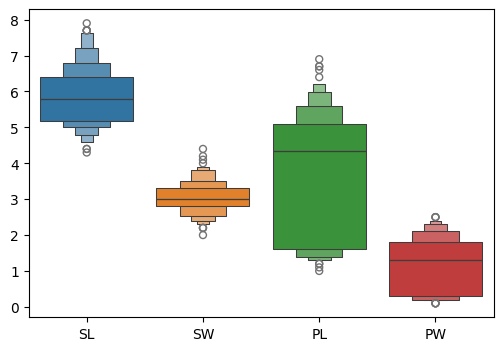

In [210]:
plt.figure(figsize = (6, 4))
sns.boxenplot(iris_data2)

**Visualize Feature Distribution and Outliers**

This step creates a box plot to show the spread, median, and potential outliers for each numerical feature.

**Syntax Explanation**

* `sns.boxplot(data)`

  * Draws a box plot using Seaborn.
* `iris_data2`

  * The dataset used for plotting.
* Useful for detecting outliers and comparing feature ranges.


<Axes: >

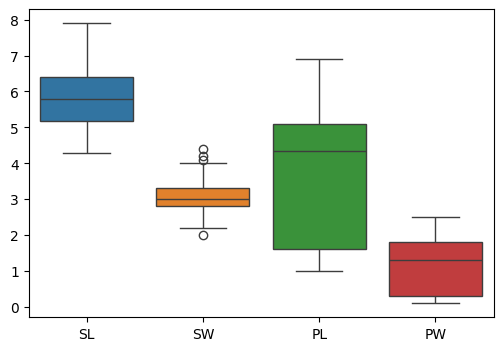

In [211]:
plt.figure(figsize = (6, 4))
sns.boxplot(iris_data2)

**Difference Between Boxen Plot and Box Plot**

**Box Plot (`sns.boxplot`)**

* Shows median, quartiles, and outliers.
* Best for small to medium datasets.
* Simple and easy to interpret.
* Outliers are shown as individual points.

**Boxen Plot (`sns.boxenplot`)**

* Shows multiple quantiles for deeper distribution detail.
* Best for large datasets.
* Reveals data density more clearly.
* Outliers are less emphasized.

**Summary**

* Use **box plot** for quick summary and teaching.
* Use **boxen plot** for detailed distribution analysis on large data.


**Visualize Distribution of a Single Feature**

This step creates a boxen plot to analyze the distribution and spread of the `SW` feature.

**Syntax Explanation**

* `sns.boxenplot(data)`

  * Draws a boxen plot using Seaborn.
* `iris_data2['SW']`

  * Passes only the `SW` column to visualize its distribution.
* Useful for identifying spread and extreme values in this feature.


<Axes: ylabel='SW'>

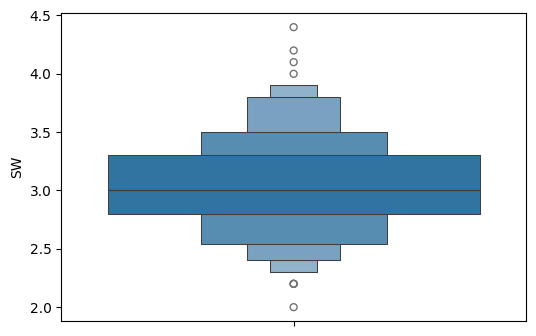

In [212]:
plt.figure(figsize = (6, 4))
sns.boxenplot(iris_data2['SW'])

**Remove Outliers and Visualize Cleaned Feature**

This step filters the `SW` feature to a reasonable range and visualizes the cleaned data to confirm outlier removal.

**Syntax Explanation**

* `iris_data2.loc[condition]`

  * `loc` filters rows based on a condition.
* `(iris_data2.SW <= 3.8) & (iris_data2.SW >= 2.5)`

  * Keeps rows where `SW` is between 2.5 and 3.8.
  * `&` means logical AND.
* `iris_data3 =`

  * Stores the filtered dataset in a new DataFrame.
* `sns.boxenplot(iris_data3['SW'])`

  * Plots the cleaned `SW` values.
* `plt.show()`

  * Displays the plot.


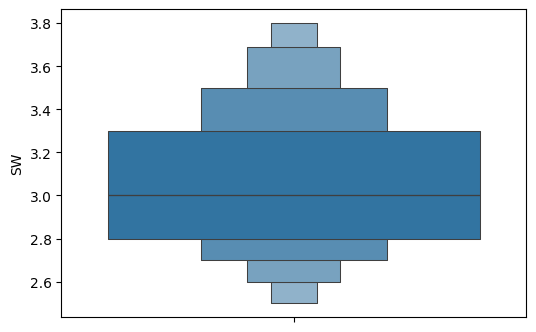

In [213]:
iris_data3 = iris_data2.loc[(iris_data2.SW <= 3.8) & (iris_data2.SW >= 2.5)]
plt.figure(figsize = (6, 4))
sns.boxenplot(iris_data3['SW'])
# sns.boxenplot(x=iris_data3['SW']) # using 'x=' argument is best practice for single variable plots
plt.show()

**View Unique Class Labels**

This step identifies all distinct species present in the filtered dataset.

**Syntax Explanation**

* `iris_data3.Species`

  * Selects the `Species` column.
* `.unique()`

  * Returns an array of unique values.
  * Useful for checking available classes after preprocessing.


In [214]:
iris_data3.Species.unique()

array(['Setosa', 'Versicolor', 'Virginica'], dtype=object)

**Encode Categorical Labels into Numerical Values**

This step converts species names into numeric labels so they can be used by machine learning algorithms.

**Syntax Explanation**

* `iris_data3.copy()`

  * Creates a separate copy to preserve previous data.
* `iris_data4.Species`

  * Selects the `Species` column.
* `.replace({'Setosa': 1, 'Versicolor': 2, 'Virginica': 3})`

  * Maps each category to a number.
* `inplace=True`

  * Applies the changes directly to the DataFrame.
* `.unique()`

  * Confirms the encoding by showing unique numeric labels.


In [215]:
iris_data4 = iris_data3.copy()
# iris_data4.Species.replace({'Setosa': 1, 'Versicolor': 2, 'Virginica': 3}, inplace = True)
iris_data4['Species'] = iris_data4['Species'].map({'Setosa': 1, 'Versicolor': 2, 'Virginica': 3})
iris_data4.Species.unique()

array([1, 2, 3])

**Initialize Encoding Tools**

This step prepares encoders to convert categorical data into numerical form for machine learning models.

**Syntax Explanation**

* `from sklearn.preprocessing import LabelEncoder, OneHotEncoder`

  * Imports encoding classes from scikit-learn.
* `LabelEncoder()`

  * Converts categorical labels into integer values.
* `OneHotEncoder()`

  * Converts categories into binary columns.
* `le =` and `ohe =`

  * Create encoder objects for later use.


In [216]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
ohe = OneHotEncoder()

**LabelEncoder Methods Overview**

These methods are used to learn category mappings and convert categorical values into numbers.

**Syntax Explanation**

* `le.fit(data)`

  * Learns unique categories from the input data.
  * No transformation happens at this step.

* `le.transform(data)`

  * Converts categories into numeric labels using the learned mapping.
  * Requires `fit()` to be called first.

* `le.fit_transform(data)`

  * Combines `fit()` and `transform()` in one step.
  * Learns categories and converts them immediately.


**Apply Label Encoding to the Target Column**

This step converts the `Species` column into numeric labels using `LabelEncoder`.

**Syntax Explanation**

* `iris_data3.copy()`

  * Creates a new copy to preserve earlier datasets.
* `iris_data5.Species`

  * Selects the `Species` column.
* `le.fit_transform(iris_data5.Species)`

  * Learns category labels and converts them into integers in one step.
* `iris_data5.Species.unique()`

  * Displays unique encoded values to confirm successful encoding.


In [217]:
iris_data5 = iris_data3.copy()
iris_data5.Species = le.fit_transform(iris_data5.Species)
iris_data5.Species.unique()

array([0, 1, 2])

**Separate Features and Target Variable**

This step identifies the class labels and splits the dataset into input features and output target.

**Syntax Explanation**

* `iris_data3.Species.unique()`

  * Displays all unique species classes in the dataset.
* `iris_data3.iloc[:, 0:-1]`

  * Selects all rows and all columns except the last one.
  * Used as input features `X`.
* `iris_data3[["Species"]]`

  * Selects the target column as a DataFrame.
  * Used as output variable `Y`.


In [218]:
iris_data3.Species.unique()

array(['Setosa', 'Versicolor', 'Virginica'], dtype=object)

In [219]:
X, Y = iris_data3.iloc[:, 0:-1], iris_data3[["Species"]]

**Preview Feature and Target Data**

This step displays the first few rows of the input features and the target variable to verify correct data separation.

**Syntax Explanation**

* `X.head(2)`

  * Shows the first 2 rows of the feature set.
* `Y.head(2)`

  * Shows the first 2 rows of the target column.
* Used to quickly check data correctness before model training.


In [220]:
X.head(2)

,SL,SW,PL,PW
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


In [221]:
Y.head(2)

,Species
0,Setosa
1,Setosa


**Apply One-Hot Encoding to Target Variable**

This step converts the categorical target values into a binary matrix representation.

**Syntax Explanation**

* `ohe.fit_transform(Y)`

  * Learns unique classes in `Y` and encodes them.
* `.toarray()`

  * Converts the sparse matrix output into a NumPy array.
* `Y_trans =`

  * Stores the one-hot encoded target data.


In [222]:
Y_trans = ohe.fit_transform(Y).toarray()
# Display only 5 records
Y_trans[:5]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

**Same Encoding Process with a Difference**

This follows the same feature–target separation and one-hot encoding process as before.

**Difference**

* Here, the `Species` column is already **label encoded** (numeric values) before applying One-Hot Encoding.
* Earlier, One-Hot Encoding was applied directly to the original categorical labels.

`N_trans` shows the one-hot encoded form of the numeric species labels.


In [223]:
iris_data5.Species.unique()

array([0, 1, 2])

In [224]:
M, N = iris_data5.iloc[:, 0:-1], iris_data5[["Species"]]

In [225]:
N_trans = ohe.fit_transform(N).toarray()
N_trans[:5]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

**Split Dataset into Training and Testing Sets**

This step divides the dataset into training and testing parts for model building and evaluation.

**Syntax Explanation**

* `train_test_split(iris_data5, train_size=0.7)`

  * Splits the dataset randomly.
  * `train_size=0.7` assigns 70% data for training.
  * Remaining 30% is used for testing.
* `test_size=0.3`

  * Alternative way to specify the same split.
* `train_data.shape`

  * Shows number of rows and columns in training data.
* `test_data.shape`

  * Shows number of rows and columns in testing data.


In [226]:
train_data, test_data = train_test_split(iris_data5, train_size = 0.7)    #  or  train_data, test_data = train_test_split(iris_data5, test_size = 0.3)

In [227]:
train_data.shape

(91, 5)

In [228]:
test_data.shape

(40, 5)

**Preview Training and Testing Data**

This step displays the first few rows of both training and testing datasets to verify that the split was performed correctly.

**Syntax Explanation**

* `train_data.head()`

  * Shows the first rows of the training dataset.
* `test_data.head()`

  * Shows the first rows of the testing dataset.
* Helps confirm random splitting and data structure.


In [229]:
train_data.head()

,SL,SW,PL,PW,Species
113,6.5,3.2,5.1,2.0,2
123,6.9,3.2,5.7,2.3,2
85,6.0,2.7,5.1,1.6,1
100,5.1,2.5,3.0,1.1,1
37,5.0,3.2,1.2,0.2,0


In [230]:
test_data.head(2)

,SL,SW,PL,PW,Species
32,5.4,3.4,1.5,0.4,0
104,7.1,3.0,5.9,2.1,2


**Stratified Train–Test Split and Data Preview**

This step splits features and target separately while preserving class distribution, then displays sample rows from each split.

**Syntax Explanation**

* `train_test_split(M, N, train_size=0.7, stratify=N, random_state=3)`

  * Splits feature set `M` and target `N` together.
  * `train_size=0.7` keeps 70% for training.
  * `stratify=N` ensures each class appears in the same proportion in train and test sets.
  * `random_state=3` fixes randomness for reproducible results.

* `train_m, test_m`

  * Training and testing feature sets.

* `train_n, test_n`

  * Training and testing target sets.

* ANSI escape codes (`\033[1m`, `\033[0m`)

  * Used to print bold headings in the output.
  * Do not affect data or model behavior.

* `head(2)`

  * Displays the first two rows to verify correct splitting.


In [231]:
train_m, test_m, train_n, test_n = train_test_split(M, N, train_size = 0.7, stratify = N, random_state = 3)

In [232]:
# ANSI escape code for bold text
BOLD = "\033[1m"
RESET = "\033[0m"

print(f"{BOLD}Training Features (M){RESET}")
print(train_m.head(2))

print(f"\n\n{BOLD}Training Target (N){RESET}")
print(train_n.head(2))

Training Features (M)
      SL   SW   PL   PW
101  5.7  2.8  4.1  1.3
18   5.7  3.8  1.7  0.3


Training Target (N)
     Species
101        1
18         0


In [233]:
# ANSI escape code for bold text
BOLD = "\033[1m"
RESET = "\033[0m"

print(f"{BOLD}Testing Features (M){RESET}")
print(test_m.head(2))

print(f"\n\n{BOLD}Testing Target (N){RESET}")
print(test_n.head(2))

Testing Features (M)
      SL   SW   PL   PW
48   5.1  3.8  1.6  0.2
139  6.3  3.4  5.6  2.4


Testing Target (N)
     Species
48         0
139        2


**Conclusion**

The dataset is successfully preprocessed, cleaned, and split into training and testing sets. Missing values were handled, categorical labels encoded, and features scaled for consistency. Outliers were removed, and visualizations confirmed the data distribution. Stratified splitting preserved class balance, ensuring that the dataset is ready for accurate and reliable model training and evaluation.